In [1]:
from sympy import Eq, symbols, Function, solve

x, y, t, dt, dx, dy, c = symbols('x y t dt dx dy c')
u = Function('u')(t, x, y)

In [2]:
continuous = Eq(u.diff(t) + c*u.diff(x) + c*u.diff(y), 0)
continuous

Eq(c*Derivative(u(t, x, y), x) + c*Derivative(u(t, x, y), y) + Derivative(u(t, x, y), t), 0)

In [3]:
u = symbols('u', cls=Function)
discrete = Eq((u(t+1, x, y)-u(t, x, y))/dt + c*((u(t, x-1, y)-u(t, x, y))/dx) + c*((u(t, x, y-1)-u(t, x, y))/dy), 0)
discrete

Eq(c*(-u(t, x, y) + u(t, x, y - 1))/dy + c*(-u(t, x, y) + u(t, x - 1, y))/dx + (-u(t, x, y) + u(t + 1, x, y))/dt, 0)

In [4]:
solution = Eq(solve(discrete, u(t+1, x, y))[0], u(t+1, x, y))
solution

Eq((c*dt*dx*(u(t, x, y) - u(t, x, y - 1)) + c*dt*dy*(u(t, x, y) - u(t, x - 1, y)) + dx*dy*u(t, x, y))/(dx*dy), u(t + 1, x, y))

In [56]:
import numpy as np
import matplotlib.pyplot as plt

width = 100
height = 100
nu = width*height

dx = 1
dy = 1
dt = 0.025
nt = 80
c = 1

u = np.ones(shape=(width, height))

def set_central_force(u):
    for x in range(width):
        for y in range(height):
            if (x > width/4 and x < 3*width/4) and (y > height/4 and y < 3*height/4):
                u[x][y] = 2
    return u

u = set_central_force(u)

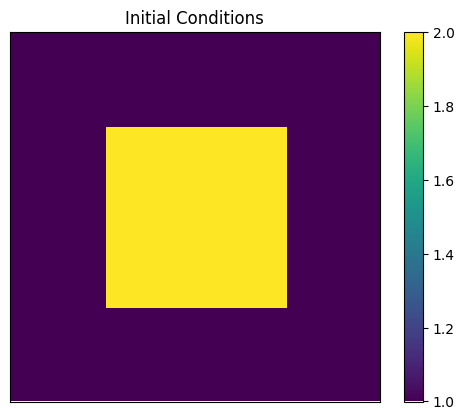

In [57]:
def plot(u, title=None):
    plt.imshow(u)
    plt.yticks([])
    plt.xticks([])
    plt.title(title)
    plt.colorbar()
    plt.show()

plot(u, title="Initial Conditions")

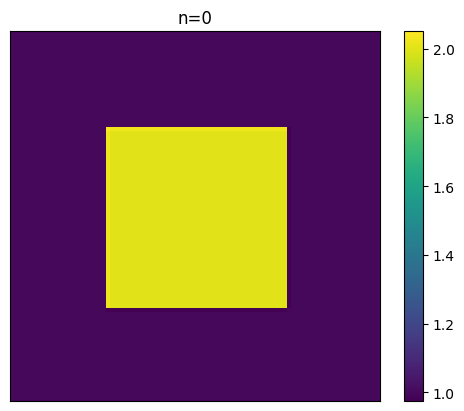

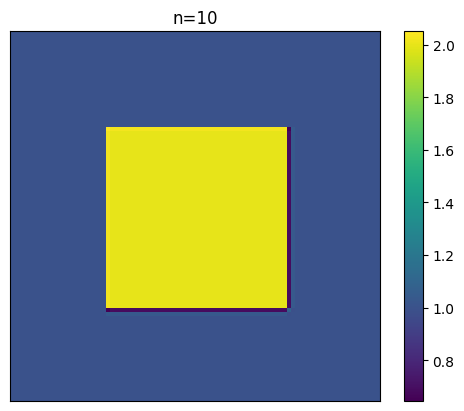

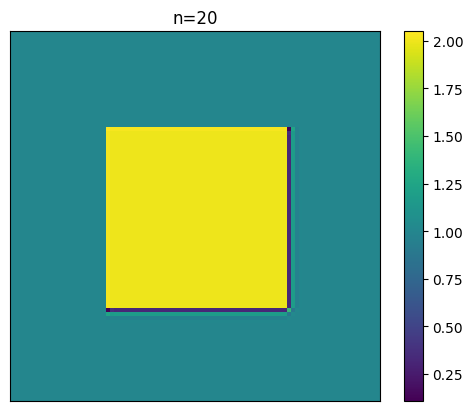

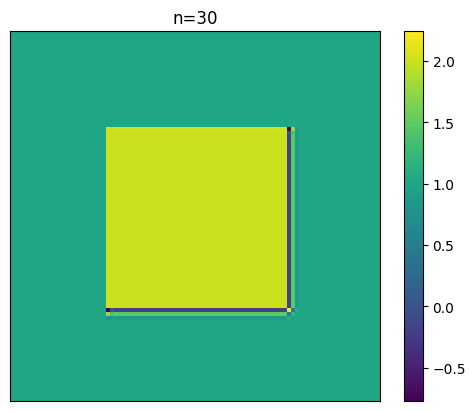

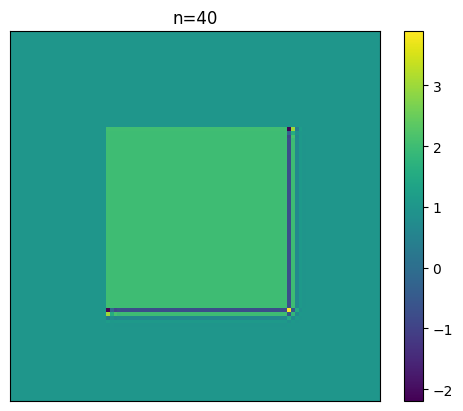

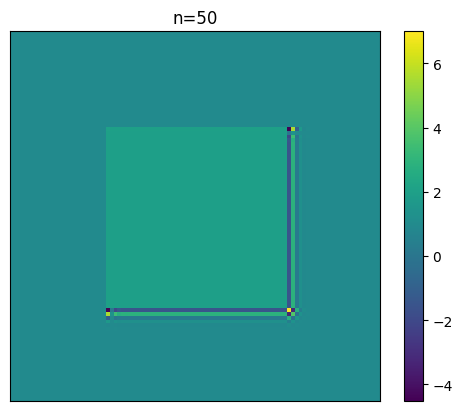

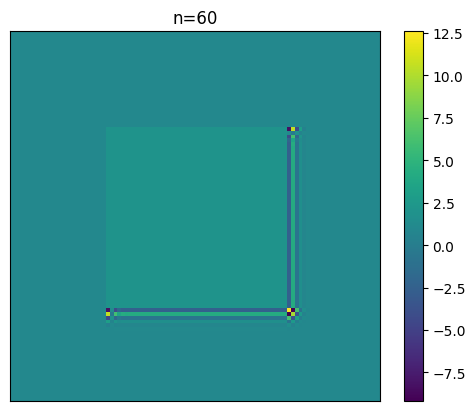

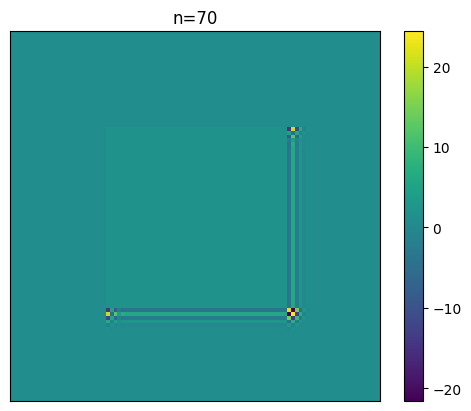

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [ ]:

for n in range(nt):
    un = u.copy()
    for x in range(1, width-1):
        for y in range(1, height-1):
            u[x][y] = (c*dt*dx*(un[x][y] - un[x][y-1]) + c*dt*dy*(un[x][y] - un[x-1][y]) + dx*dy*un[x][y]) / (dx*dy)
    if n % 10 == 0:
        plot(u, title=f"n={n}")
u